In [ ]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style for better looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [ ]:
# Load the Master_combined sheet from your Excel file
df = pd.read_excel('Book1.xlsx', sheet_name='Master_combined')

print("✅ Data loaded successfully!")
print(f"📊 Total rows: {len(df)}")
print(f"📊 Total columns: {len(df.columns)}")
print(f"📊 Columns: {df.columns.tolist()}")
print("\n📋 First 5 rows:")
df.head()

✅ Data loaded successfully!
📊 Total rows: 661
📊 Total columns: 13
📊 Columns: ['City', 'Station_id', 'Year', 'manganese', 'iron', 'nitrate', 'EC', 'pH', 'chloride', 'sulfate', 'temperature', 'rainfall', 'SPI']

📋 First 5 rows:


,City,Station_id,Year,manganese,iron,nitrate,EC,pH,chloride,sulfate,temperature,rainfall,SPI
0,Cologne,10406426,2015,0.00010,0.000100,0.027865,2230.00,6.50,0.001375,0.025000,11.17,757.1,-0.30
1,Cologne,10201117,2016,0.00005,0.000050,0.005763,969.00,7.10,0.000440,0.066000,10.87,714.3,-0.60
2,Cologne,10201531,2016,0.00005,0.000100,0.027865,340.00,6.00,0.001580,0.180000,10.87,714.3,-0.60
3,Cologne,10406426,2016,0.00005,0.000075,0.027865,2530.00,6.50,0.001000,0.009667,10.87,714.3,-0.60
4,Cologne,10201531,2017,0.00005,0.000100,0.019085,399.62,6.15,0.003150,0.175000,11.20,842.7,0.31


In [ ]:
print("=" * 60)
print("📊 DATASET OVERVIEW")
print("=" * 60)

print(f"\n📌 Total rows: {df.shape[0]}")
print(f"📌 Total columns: {df.shape[1]}")

print("\n--- Cities in the dataset ---")
print(df['City'].value_counts())

print("\n--- Years in the dataset ---")
print(df['Year'].value_counts().sort_index())

print("\n--- Unique stations per city ---")
print(df.groupby('City')['Station_id'].nunique())

📊 DATASET OVERVIEW

📌 Total rows: 661
📌 Total columns: 13

--- Cities in the dataset ---
City
Leipzig      378
Cologne      144
Stuttgart    139
Name: count, dtype: int64

--- Years in the dataset ---
Year
2015    63
2016    62
2017    64
2018    62
2019    77
2020    84
2021    72
2022    55
2023    57
2024    65
Name: count, dtype: int64

--- Unique stations per city ---
City
Cologne       43
Leipzig      287
Stuttgart    139
Name: Station_id, dtype: int64


In [ ]:
print("=" * 60)
print("🔍 MISSING VALUE ANALYSIS")
print("=" * 60)

# Calculate missing values
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame for missing values
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("\n--- Parameters with missing values ---")
print(missing_df)

# Save to Excel
if len(missing_df) > 0:
    missing_df.to_excel('missing_values_report.xlsx')
    print("\n✅ Missing values report saved to: missing_values_report.xlsx")
else:
    print("\n✅ No missing values found in any column!")

# Missing values by city
print("\n--- Missing values by city ---")
for city in df['City'].unique():
    city_df = df[df['City'] == city]
    missing_city = city_df.isnull().sum()
    missing_city = missing_city[missing_city > 0]
    if len(missing_city) > 0:
        print(f"\n📌 {city}:")
        print(missing_city)

🔍 MISSING VALUE ANALYSIS

--- Parameters with missing values ---
           Missing Count  Missing %
manganese            318  48.108926
iron                 314  47.503782
sulfate               59   8.925870
chloride              59   8.925870
nitrate                9   1.361573
EC                     6   0.907716
pH                     4   0.605144

✅ Missing values report saved to: missing_values_report.xlsx

--- Missing values by city ---

📌 Leipzig:
manganese    234
iron         234
nitrate        8
EC             2
dtype: int64

📌 Stuttgart:
manganese    84
iron         80
nitrate       1
EC            4
pH            4
chloride     59
sulfate      59
dtype: int64


In [ ]:
print("=" * 60)
print("📊 SUMMARY STATISTICS")
print("=" * 60)

# List of numerical columns
param_columns = ['manganese', 'iron', 'nitrate', 'EC', 'pH', 'chloride', 'sulfate',
                 'temperature', 'rainfall', 'SPI']

print("\n--- Summary Statistics for All Parameters ---")
summary_stats = df[param_columns].describe()
print(summary_stats)

# Save to Excel
summary_stats.to_excel('summary_statistics.xlsx')
print("\n✅ Summary statistics saved to: summary_statistics.xlsx")

# Additional statistics by city
print("\n--- Summary by City (Mean values) ---")
city_means = df.groupby('City')[param_columns].mean()
print(city_means)

📊 SUMMARY STATISTICS

--- Summary Statistics for All Parameters ---
        manganese        iron     nitrate           EC          pH  \
count  343.000000  347.000000  652.000000   655.000000  657.000000   
mean     0.168618    0.343023   11.701707  1064.030209    6.805098   
std      0.471225    1.229921   17.458044   435.595309    0.580736   
min      0.000050    0.000050    0.000000    50.000000    3.450000   
25%      0.000300    0.000175    0.100000   755.500000    6.700000   
50%      0.001100    0.005000    2.250000  1050.000000    6.900000   
75%      0.038500    0.015000   17.000000  1275.000000    7.100000   
max      4.686000    8.100000  120.000000  3110.000000    7.900000   

         chloride      sulfate  temperature     rainfall         SPI  
count  602.000000   602.000000   661.000000   661.000000  661.000000  
mean    70.846076   236.643961    11.010166   596.084720   -0.020378  
std     69.432937   195.571587     0.623161   184.425367    0.953190  
min      0.000000

In [ ]:
print("=" * 60)
print("⚠️ OUTLIER DETECTION")
print("=" * 60)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return {
        'column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': len(outliers),
        'outlier_percent': (len(outliers) / len(data)) * 100,
        'outliers': outliers
    }

# Parameters to check for outliers
param_columns = ['manganese', 'iron', 'nitrate', 'EC', 'chloride', 'sulfate']

outlier_summary = []

for col in param_columns:
    try:
        result = detect_outliers_iqr(df, col)
        outlier_summary.append({
            'Parameter': col,
            'Outlier Count': result['outlier_count'],
            'Outlier %': round(result['outlier_percent'], 2),
            'Lower Bound': round(result['lower_bound'], 4),
            'Upper Bound': round(result['upper_bound'], 4)
        })
        print(f"\n📌 {col.upper()}:")
        print(f"   Outliers: {result['outlier_count']} rows ({result['outlier_percent']:.2f}%)")
        print(f"   Normal range: {result['lower_bound']:.4f} to {result['upper_bound']:.4f}")

        if result['outlier_count'] > 0 and result['outlier_count'] < 20:
            print(f"   Example outliers (first 5):")
            out_rows = result['outliers'][['City', 'Station_id', 'Year', col]].head(5)
            print(out_rows.to_string(index=False))
        elif result['outlier_count'] >= 20:
            print(f"   ⚠️ {result['outlier_count']} outliers found - too many to list")
    except Exception as e:
        print(f"\n{col.upper()}: Error - {e}")

# Save outlier summary
outlier_df = pd.DataFrame(outlier_summary)
outlier_df.to_excel('outlier_report.xlsx', index=False)
print("\n✅ Outlier report saved to: outlier_report.xlsx")

⚠️ OUTLIER DETECTION

📌 MANGANESE:
   Outliers: 64 rows (9.68%)
   Normal range: -0.0570 to 0.0958
   ⚠️ 64 outliers found - too many to list

📌 IRON:
   Outliers: 49 rows (7.41%)
   Normal range: -0.0221 to 0.0372
   ⚠️ 49 outliers found - too many to list

📌 NITRATE:
   Outliers: 44 rows (6.66%)
   Normal range: -25.2500 to 42.3500
   ⚠️ 44 outliers found - too many to list

📌 EC:
   Outliers: 17 rows (2.57%)
   Normal range: -23.7500 to 2054.2500
   Example outliers (first 5):
     City                                                            Station_id  Year     EC
  Cologne                                                              10406426  2015 2230.0
  Cologne                                                              10406426  2016 2530.0
Stuttgart GWM 10.2 Langwiesenweg  EnBW Kraftwerke AG, Stuttgart-Ost, 2011/512-0  2015 2870.0
Stuttgart GWM 10.2 Langwiesenweg  EnBW Kraftwerke AG, Stuttgart-Ost, 2011/512-1  2016 3110.0
Stuttgart                        GWM 9 Hauffstraße

📈 CORRELATION MATRIX

--- Correlation Matrix ---
             manganese      iron   nitrate        EC        pH  chloride  \
manganese     1.000000  0.526428  0.022178  0.430024  0.030419  0.312149   
iron          0.526428  1.000000 -0.138967  0.285317  0.157119  0.230965   
nitrate       0.022178 -0.138967  1.000000  0.215035  0.028466  0.245757   
EC            0.430024  0.285317  0.215035  1.000000  0.183309  0.698892   
pH            0.030419  0.157119  0.028466  0.183309  1.000000  0.129121   
chloride      0.312149  0.230965  0.245757  0.698892  0.129121  1.000000   
sulfate       0.492566  0.334436  0.302209  0.771152  0.092975  0.525033   
temperature  -0.199470 -0.161788 -0.175623 -0.267115 -0.152495 -0.305906   
rainfall     -0.226931 -0.198709 -0.230763 -0.285870 -0.096251 -0.319720   
SPI          -0.097692 -0.075185 -0.039848 -0.080020 -0.062255 -0.072245   

              sulfate  temperature  rainfall       SPI  
manganese    0.492566    -0.199470 -0.226931 -0.097692  


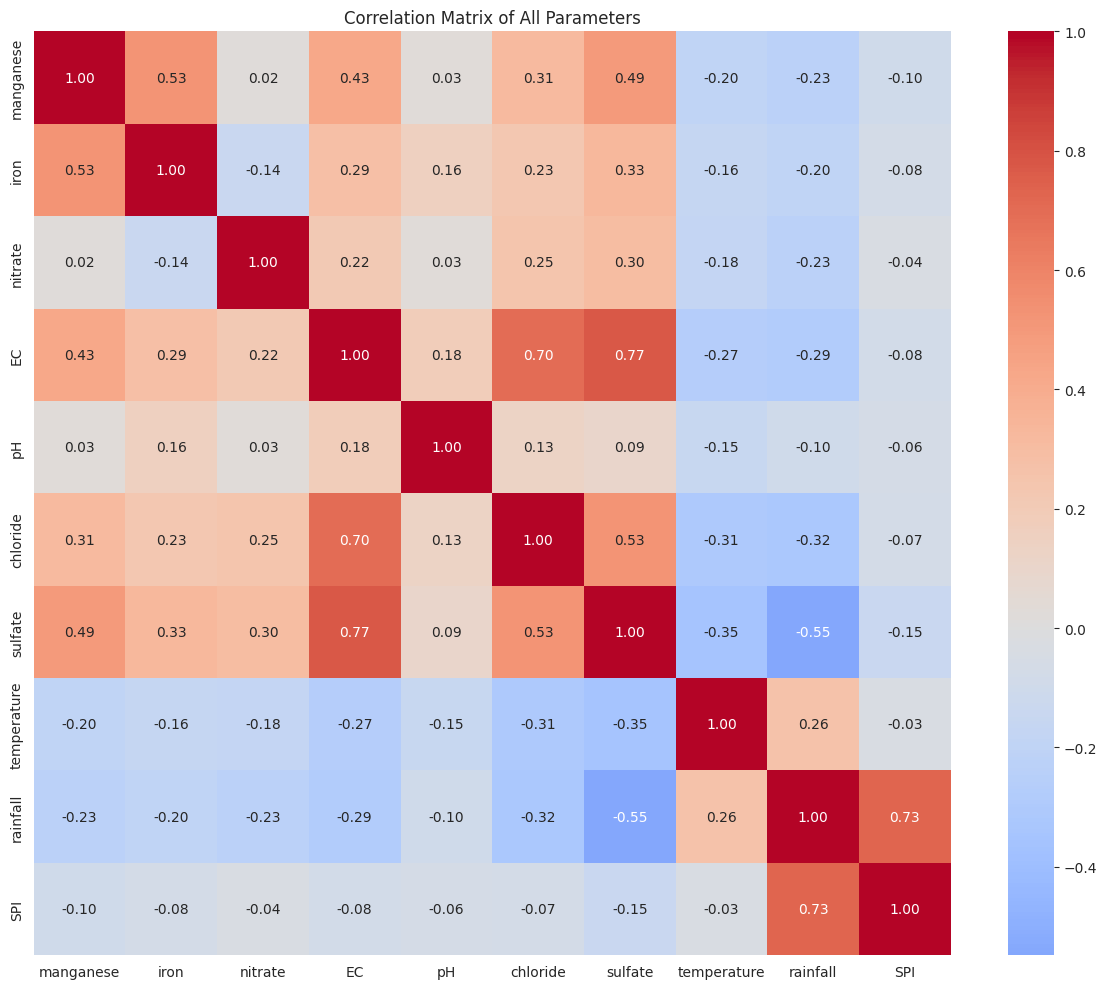

✅ Correlation heatmap saved to: correlation_heatmap.png

--- Climate vs Groundwater Correlations ---

📌 TEMPERATURE vs Groundwater:
   EC: -0.267
   nitrate: -0.176
   chloride: -0.306
   sulfate: -0.350
   pH: -0.152

📌 RAINFALL vs Groundwater:
   EC: -0.286
   nitrate: -0.231
   chloride: -0.320
   sulfate: -0.548
   pH: -0.096

📌 SPI vs Groundwater:
   EC: -0.080
   nitrate: -0.040
   chloride: -0.072
   sulfate: -0.146
   pH: -0.062


In [ ]:
print("=" * 60)
print("📈 CORRELATION MATRIX")
print("=" * 60)

# List of numerical columns
param_columns = ['manganese', 'iron', 'nitrate', 'EC', 'pH', 'chloride', 'sulfate',
                 'temperature', 'rainfall', 'SPI']

# Calculate correlation matrix
corr_matrix = df[param_columns].corr()

print("\n--- Correlation Matrix ---")
print(corr_matrix)

# Save to Excel
corr_matrix.to_excel('correlation_matrix.xlsx')
print("\n✅ Correlation matrix saved to: correlation_matrix.xlsx")

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of All Parameters')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()
print("✅ Correlation heatmap saved to: correlation_heatmap.png")

# Highlight climate vs groundwater correlations
print("\n--- Climate vs Groundwater Correlations ---")
climate_params = ['temperature', 'rainfall', 'SPI']
gw_params = ['EC', 'nitrate', 'chloride', 'sulfate', 'pH']

for climate in climate_params:
    print(f"\n📌 {climate.upper()} vs Groundwater:")
    for gw in gw_params:
        corr = df[climate].corr(df[gw])
        print(f"   {gw}: {corr:.3f}")

📊 GENERATING DISTRIBUTION PLOTS


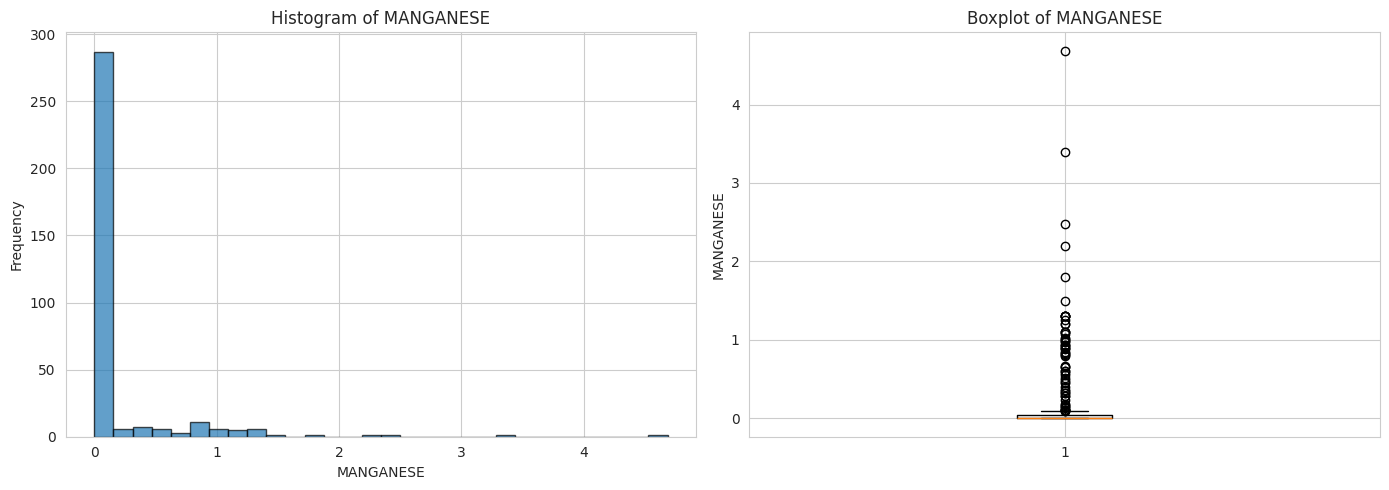

✅ Saved: distribution_manganese.png


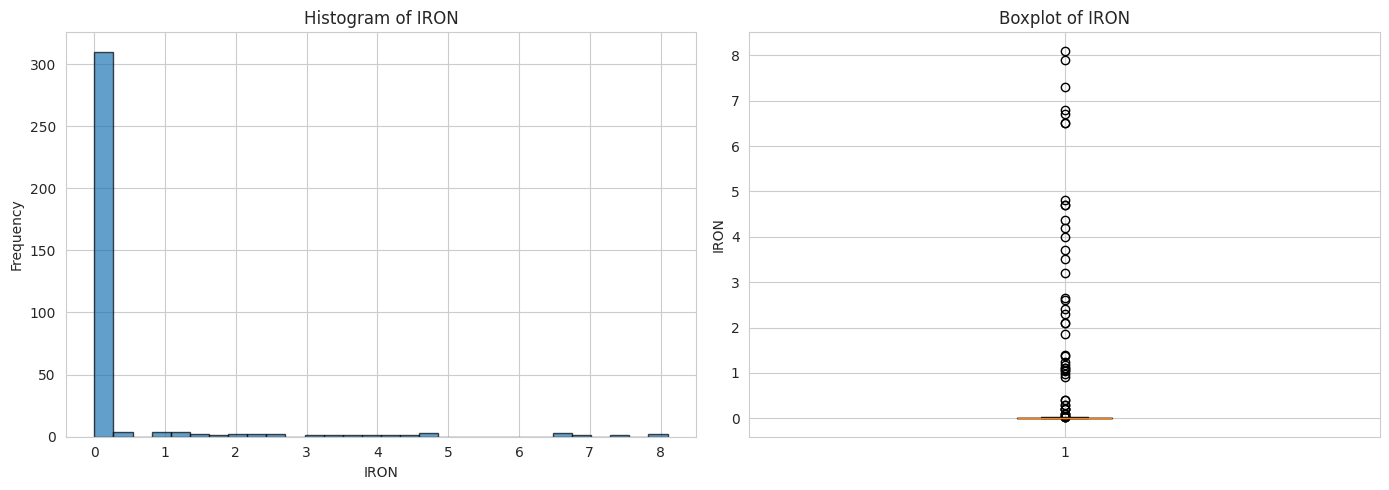

✅ Saved: distribution_iron.png


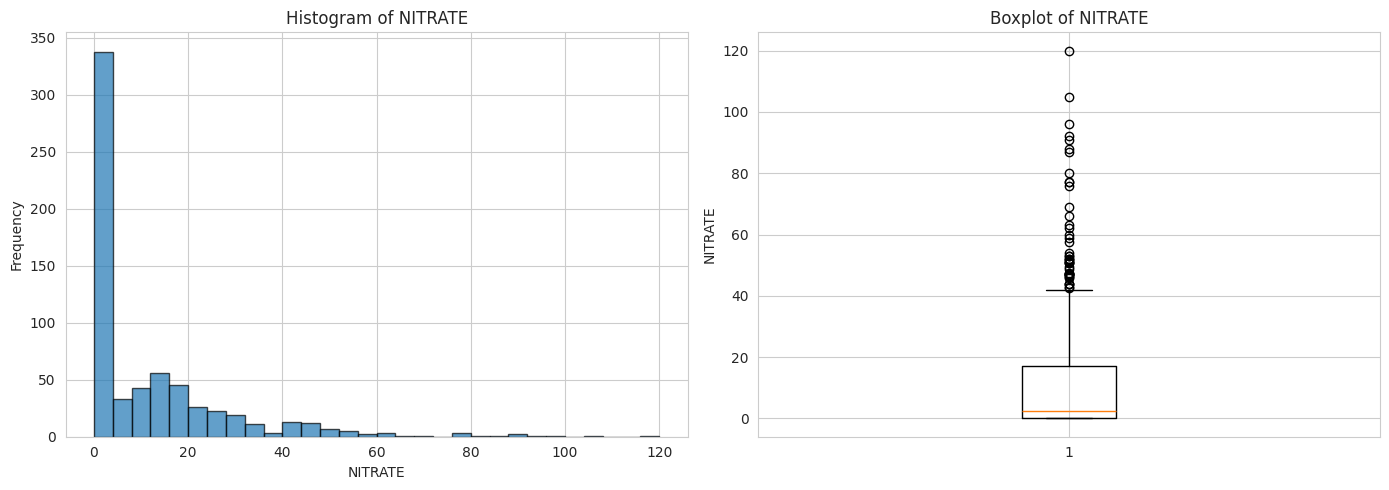

✅ Saved: distribution_nitrate.png


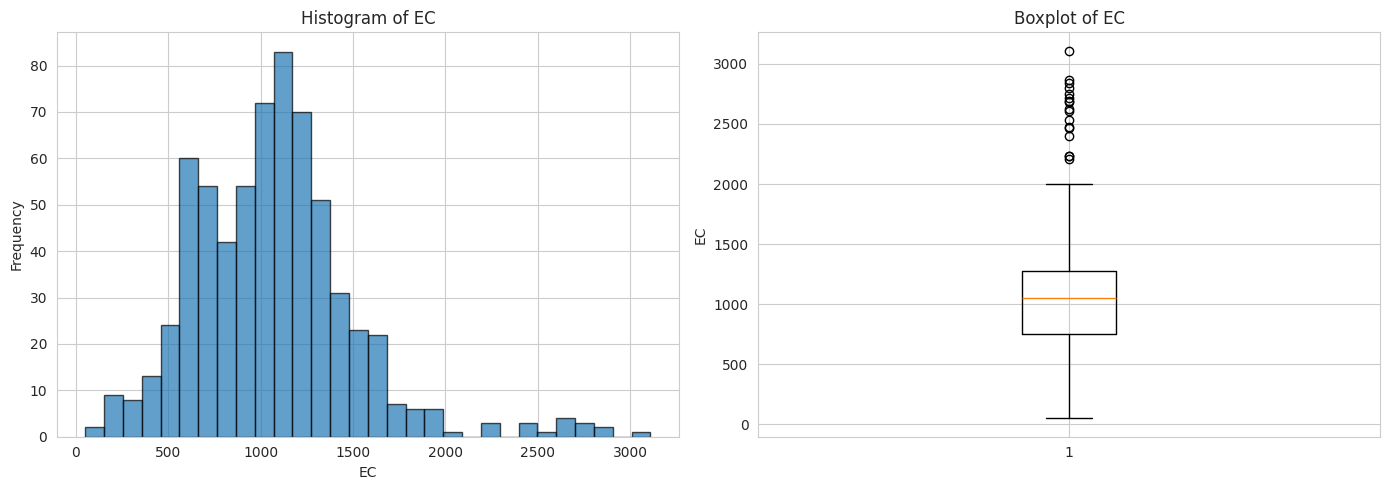

✅ Saved: distribution_EC.png


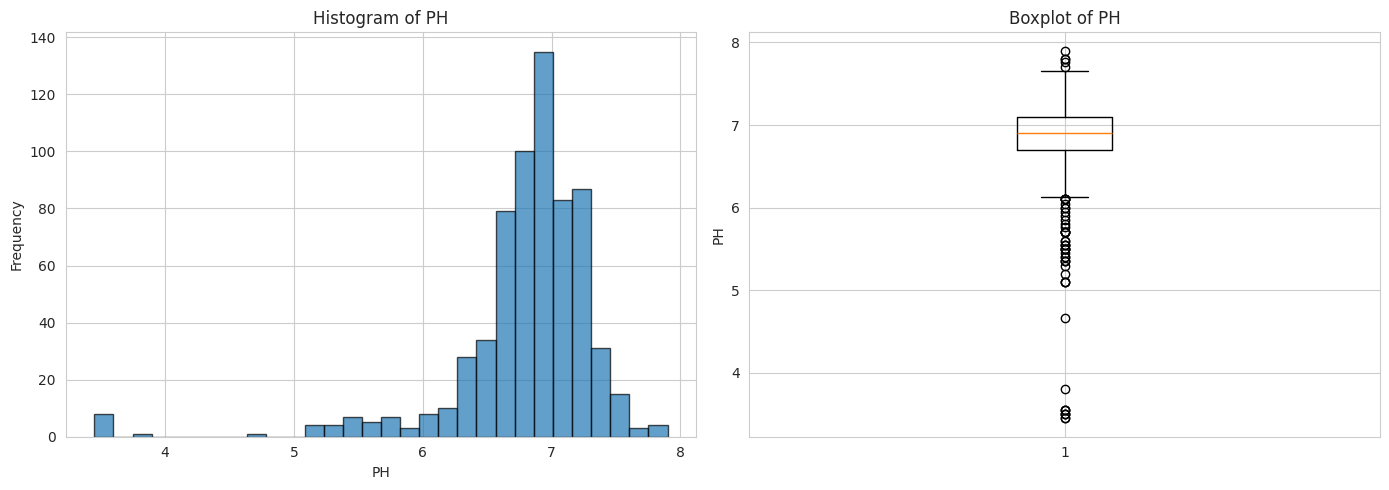

✅ Saved: distribution_pH.png


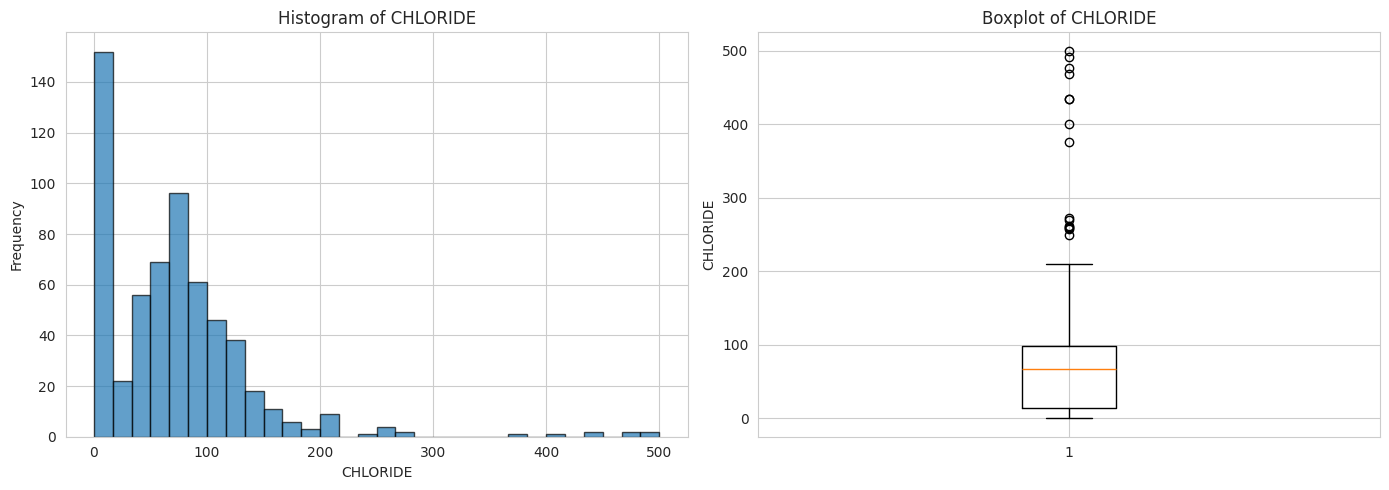

✅ Saved: distribution_chloride.png


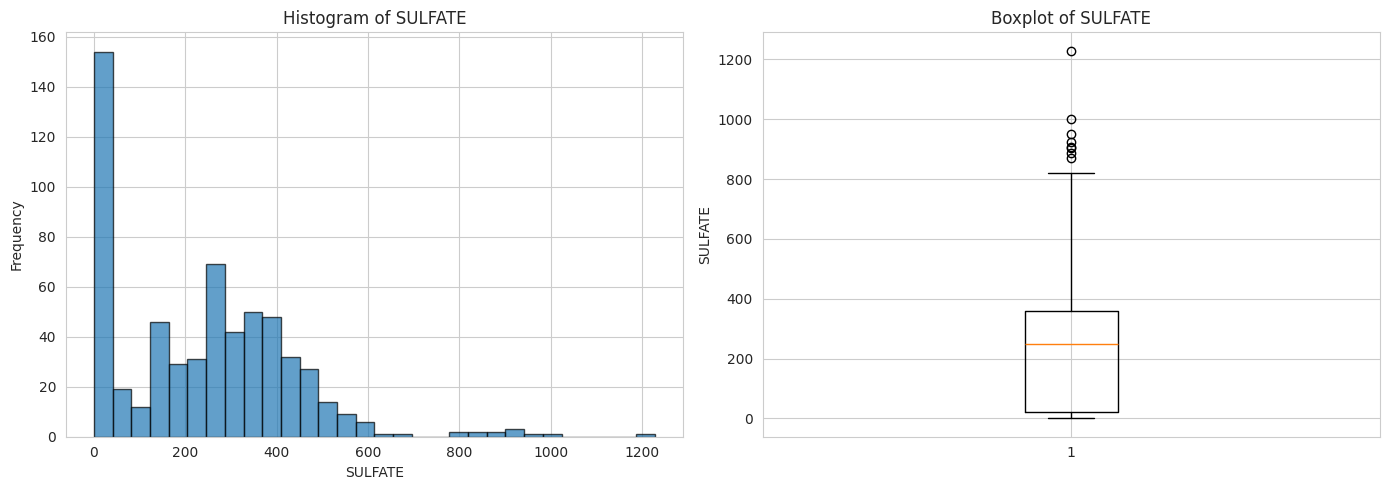

✅ Saved: distribution_sulfate.png


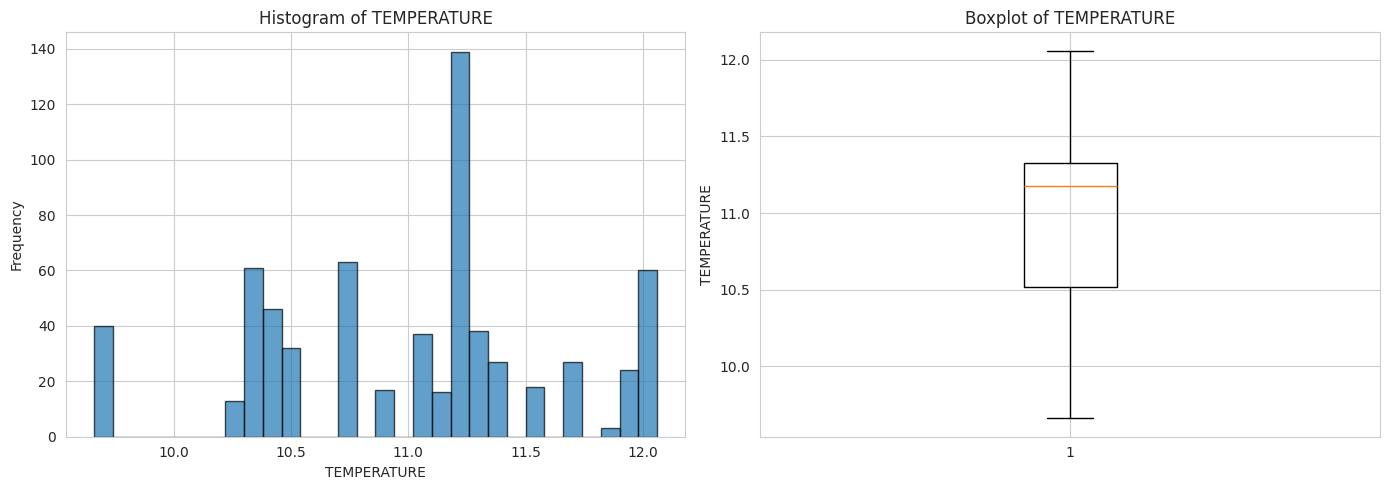

✅ Saved: distribution_temperature.png


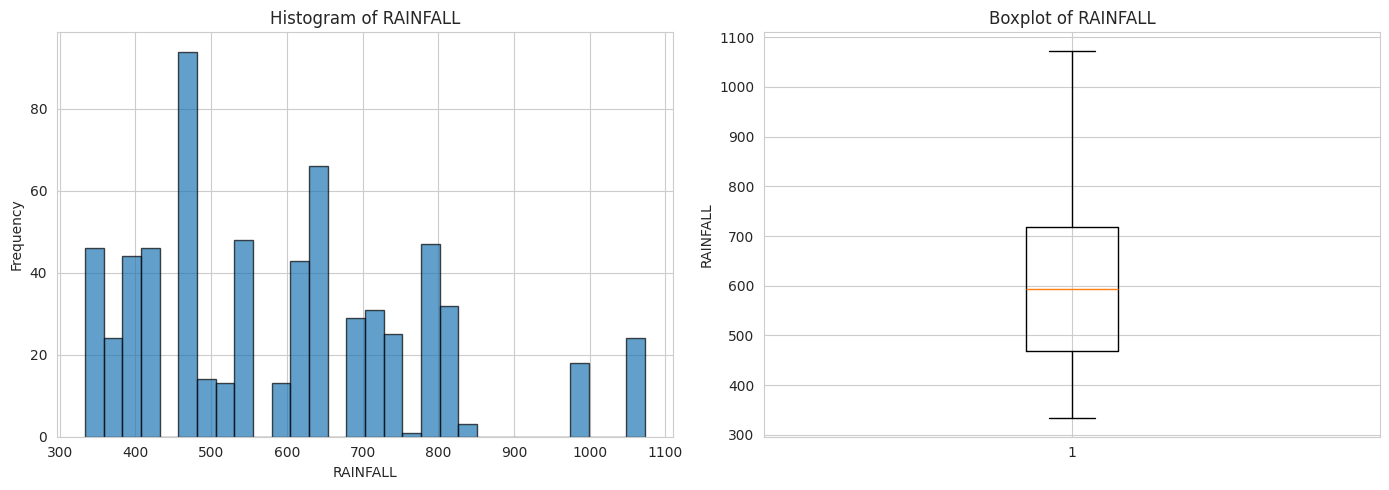

✅ Saved: distribution_rainfall.png


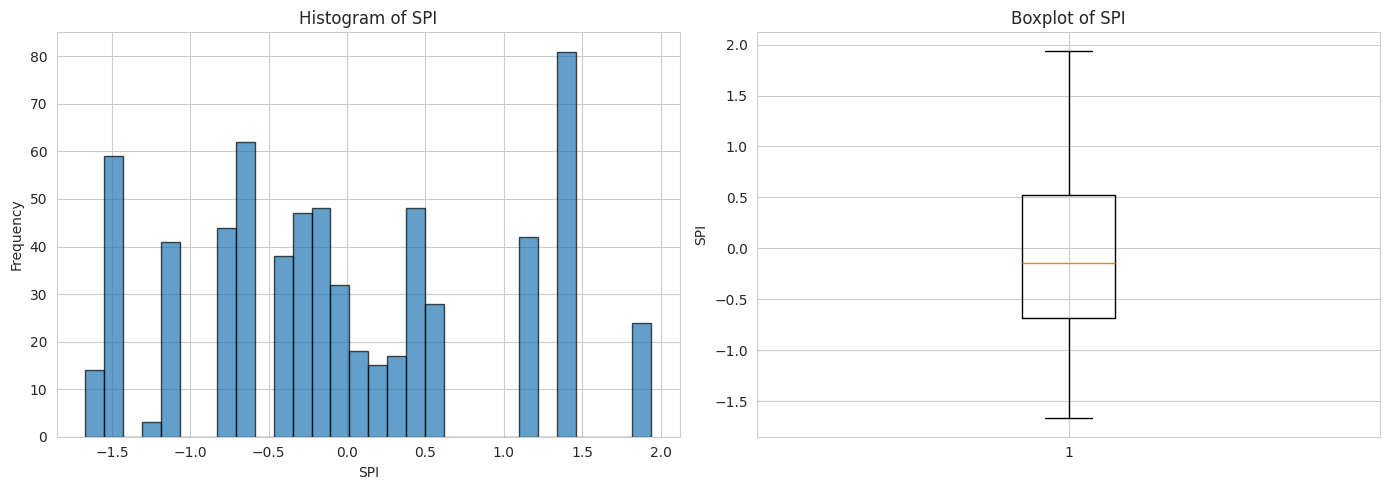

✅ Saved: distribution_SPI.png


In [ ]:
print("=" * 60)
print("📊 GENERATING DISTRIBUTION PLOTS")
print("=" * 60)

# Parameters to plot
param_columns = ['manganese', 'iron', 'nitrate', 'EC', 'pH', 'chloride', 'sulfate',
                 'temperature', 'rainfall', 'SPI']

for col in param_columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    axes[0].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_title(f'Histogram of {col.upper()}')
    axes[0].set_xlabel(col.upper())
    axes[0].set_ylabel('Frequency')

    # Boxplot
    axes[1].boxplot(df[col].dropna())
    axes[1].set_title(f'Boxplot of {col.upper()}')
    axes[1].set_ylabel(col.upper())

    plt.tight_layout()
    plt.savefig(f'distribution_{col}.png', dpi=300)
    plt.show()
    print(f"✅ Saved: distribution_{col}.png")

📊 BOXPLOTS BY CITY


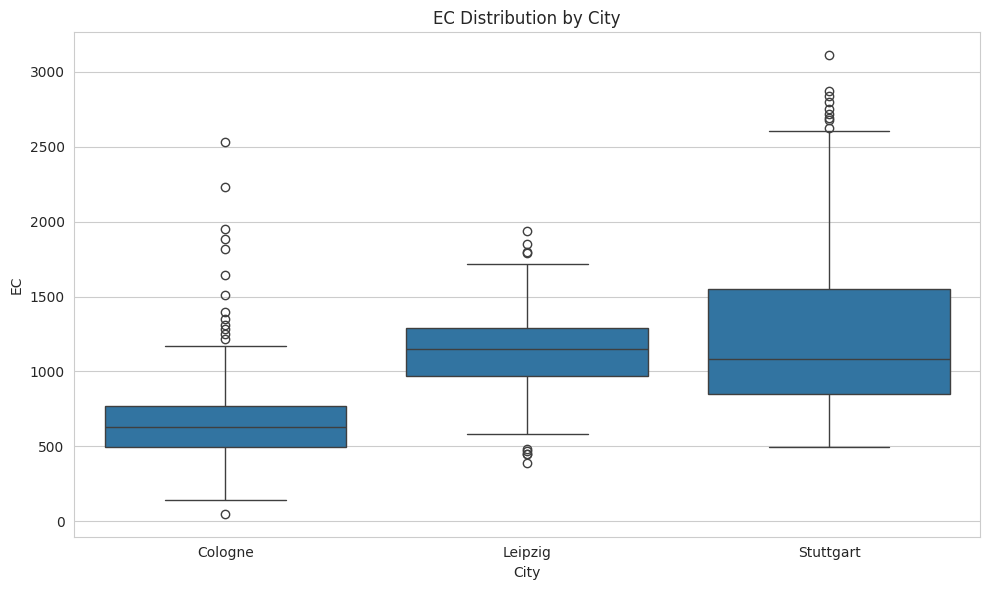

✅ Saved: boxplot_by_city_EC.png


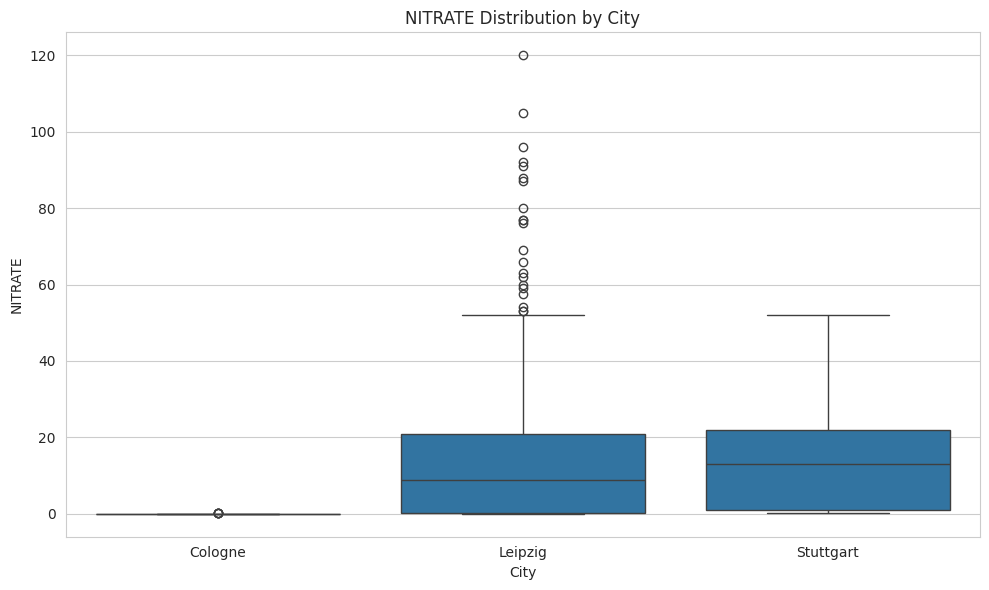

✅ Saved: boxplot_by_city_nitrate.png


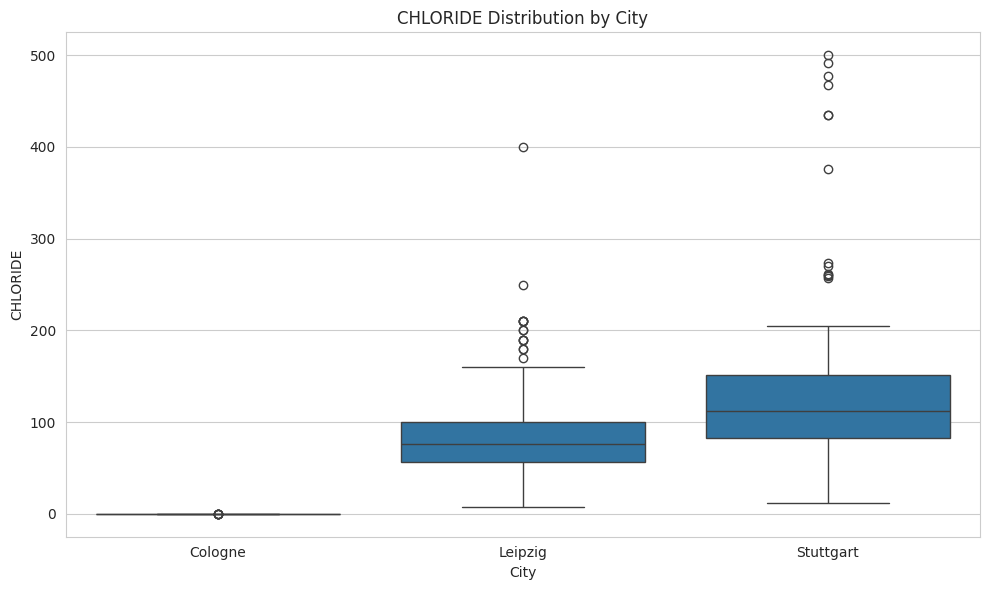

✅ Saved: boxplot_by_city_chloride.png


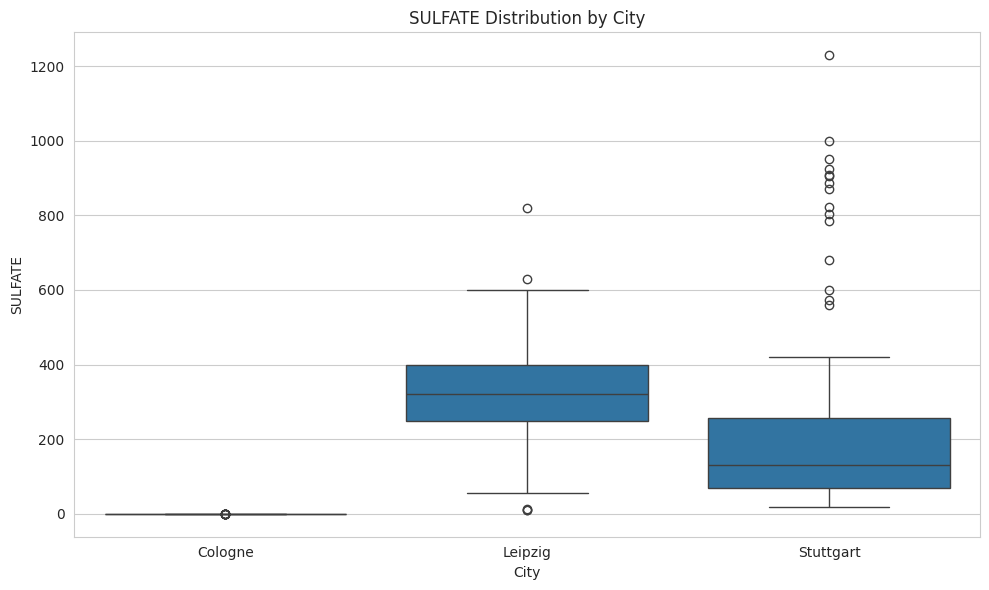

✅ Saved: boxplot_by_city_sulfate.png


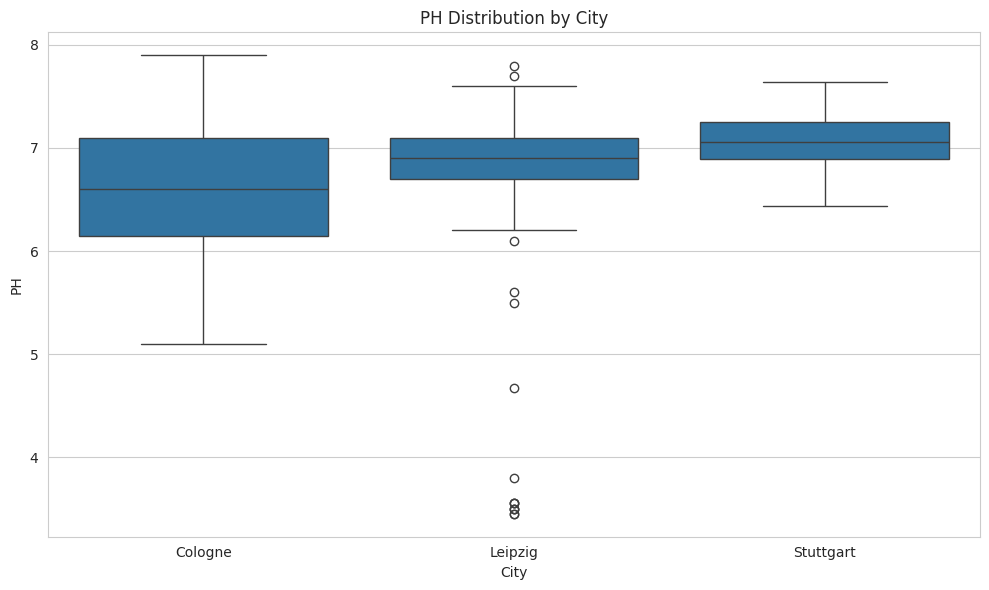

✅ Saved: boxplot_by_city_pH.png


In [ ]:
print("=" * 60)
print("📊 BOXPLOTS BY CITY")
print("=" * 60)

param_columns = ['EC', 'nitrate', 'chloride', 'sulfate', 'pH']

for col in param_columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='City', y=col, data=df)
    plt.title(f'{col.upper()} Distribution by City')
    plt.xlabel('City')
    plt.ylabel(col.upper())
    plt.tight_layout()
    plt.savefig(f'boxplot_by_city_{col}.png', dpi=300)
    plt.show()
    print(f"✅ Saved: boxplot_by_city_{col}.png")

📈 TIME SERIES PLOTS


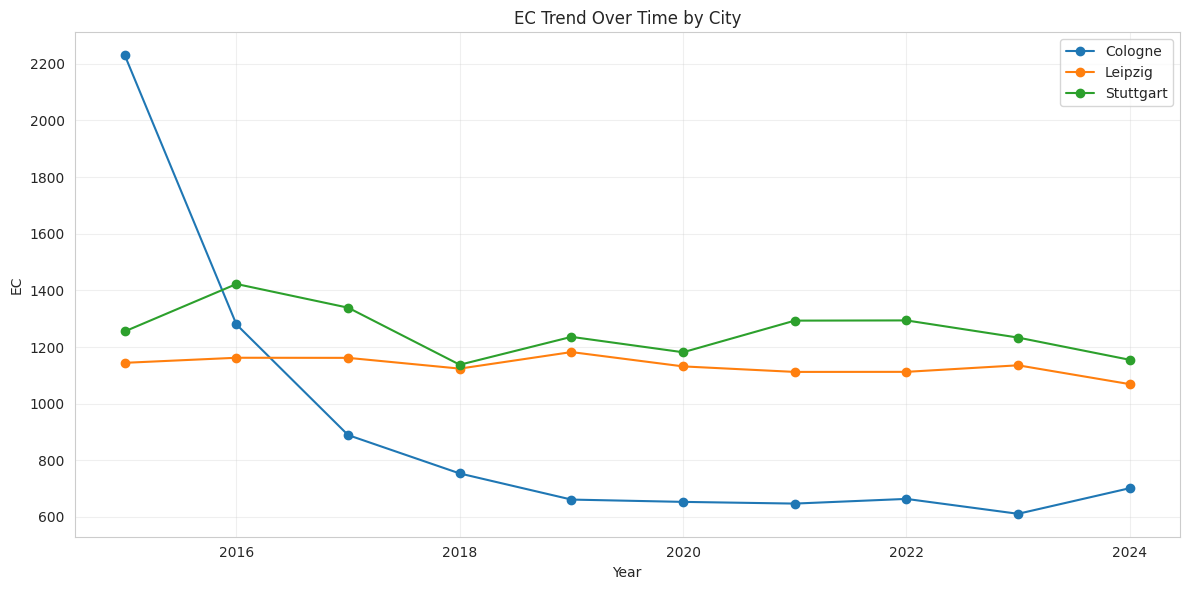

✅ Saved: timeseries_EC.png


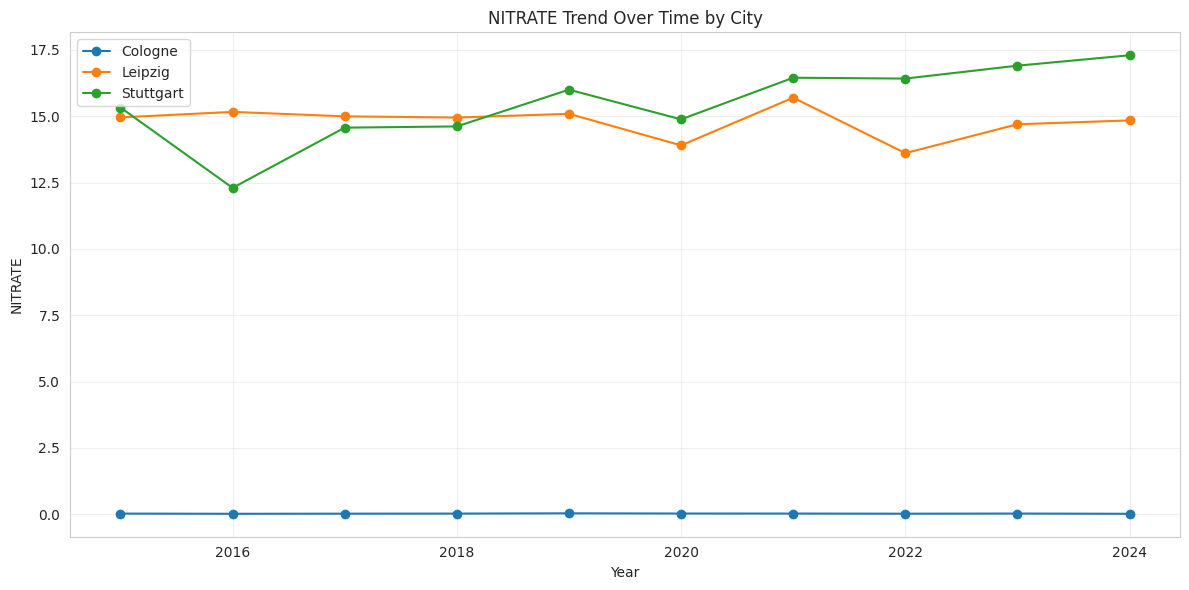

✅ Saved: timeseries_nitrate.png


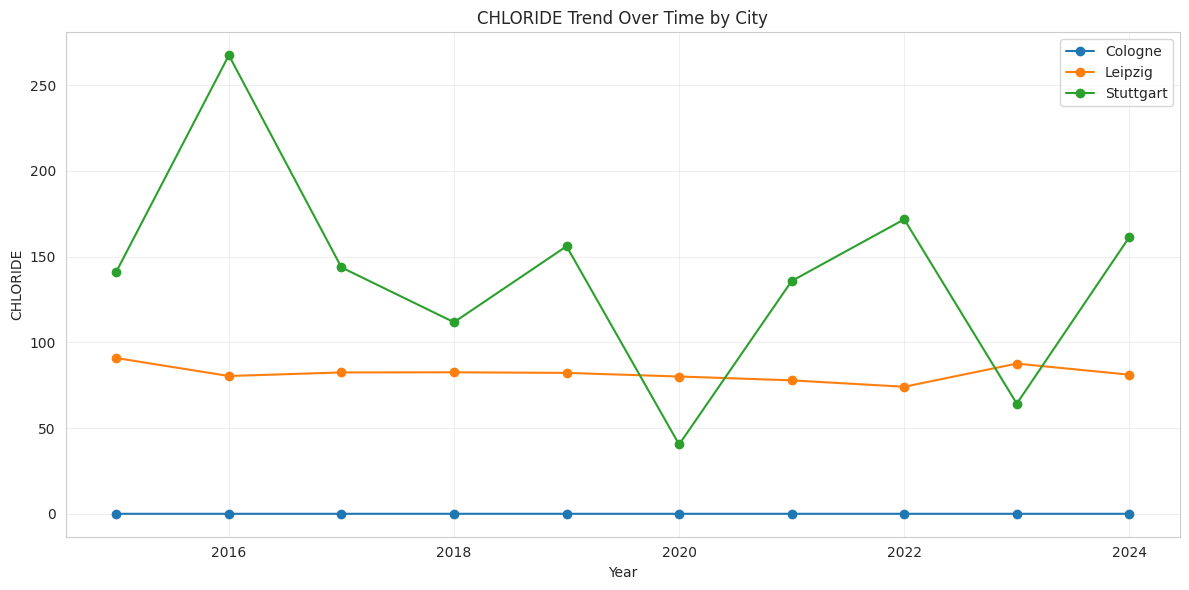

✅ Saved: timeseries_chloride.png


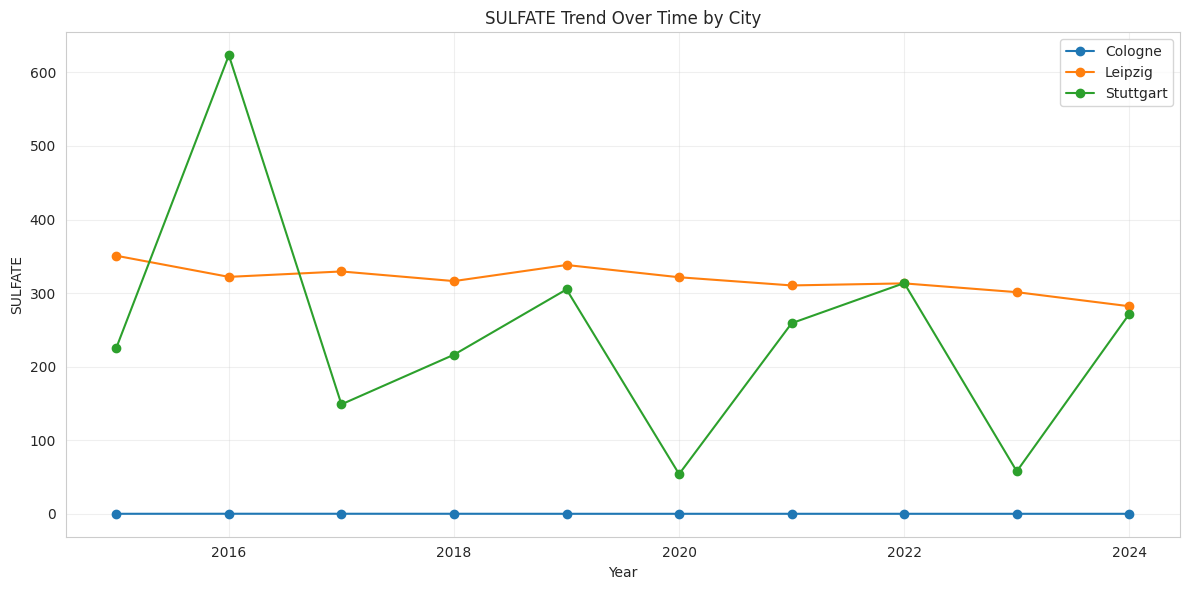

✅ Saved: timeseries_sulfate.png


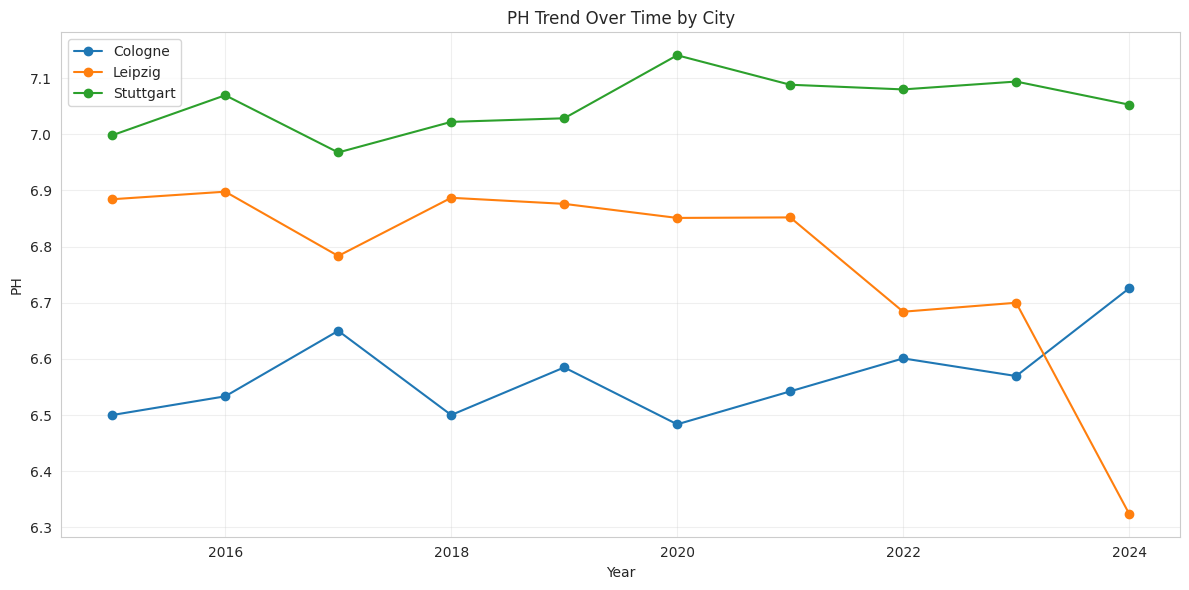

✅ Saved: timeseries_pH.png


In [ ]:
print("=" * 60)
print("📈 TIME SERIES PLOTS")
print("=" * 60)

param_columns = ['EC', 'nitrate', 'chloride', 'sulfate', 'pH']

for col in param_columns:
    plt.figure(figsize=(12, 6))

    for city in df['City'].unique():
        city_data = df[df['City'] == city]
        yearly_mean = city_data.groupby('Year')[col].mean()
        plt.plot(yearly_mean.index, yearly_mean.values, marker='o', label=city)

    plt.title(f'{col.upper()} Trend Over Time by City')
    plt.xlabel('Year')
    plt.ylabel(col.upper())
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'timeseries_{col}.png', dpi=300)
    plt.show()
    print(f"✅ Saved: timeseries_{col}.png")

In [ ]:
print("=" * 60)
print("📄 GENERATING DATA QUALITY REPORT")
print("=" * 60)

with open('Data_Quality_Report.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("DATA QUALITY ASSESSMENT REPORT\n")
    f.write("Groundwater Quality Forecasting Project\n")
    f.write(f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 80 + "\n\n")

    f.write("1. DATASET OVERVIEW\n")
    f.write("-" * 40 + "\n")
    f.write(f"Total rows: {df.shape[0]}\n")
    f.write(f"Total columns: {df.shape[1]}\n")
    f.write(f"Cities: {df['City'].unique().tolist()}\n")
    f.write(f"Years: {df['Year'].min()} - {df['Year'].max()}\n")
    f.write(f"Total unique stations: {df['Station_id'].nunique()}\n\n")

    f.write("2. MISSING VALUES\n")
    f.write("-" * 40 + "\n")
    if len(missing_df) > 0:
        f.write(missing_df.to_string())
    else:
        f.write("No missing values found!")
    f.write("\n\n")

    f.write("3. SUMMARY STATISTICS\n")
    f.write("-" * 40 + "\n")
    f.write(summary_stats.to_string())
    f.write("\n\n")

    f.write("4. OUTLIER SUMMARY\n")
    f.write("-" * 40 + "\n")
    f.write(outlier_df.to_string())
    f.write("\n\n")

    f.write("5. CITY COMPARISON (Mean Values)\n")
    f.write("-" * 40 + "\n")
    f.write(city_means.to_string())
    f.write("\n\n")

    f.write("6. KEY INSIGHTS\n")
    f.write("-" * 40 + "\n")
    f.write("• Stuttgart shows highest EC, chloride, and sulfate concentrations\n")
    f.write("• Leipzig shows highest nitrate concentrations\n")
    f.write("• Cologne shows lowest concentrations across all parameters\n")
    f.write("• Stuttgart shows declining trends in EC, chloride, and sulfate (2016-2024)\n")
    f.write("• Leipzig shows declining nitrate trend\n")
    f.write("• pH is stable across all cities\n")
    f.write("\n")

    f.write("7. DATA QUALITY NOTES\n")
    f.write("-" * 40 + "\n")
    f.write("• Manganese and iron have the highest missing rates (48% and 47%)\n")
    f.write("• Chloride and sulfate have 8.9% missing values (Stuttgart only)\n")
    f.write("• Stuttgart is the most challenging city for modeling (extreme values)\n")
    f.write("• Check generated plots for visual inspection\n")

print("\n✅ Data Quality Report saved to: Data_Quality_Report.txt")

📄 GENERATING DATA QUALITY REPORT

✅ Data Quality Report saved to: Data_Quality_Report.txt


In [ ]:
print("\n" + "=" * 60)
print("📁 FILES GENERATED")
print("=" * 60)
print("""
📊 Excel Files:
  ✅ missing_values_report.xlsx
  ✅ summary_statistics.xlsx
  ✅ outlier_report.xlsx
  ✅ correlation_matrix.xlsx

📈 Plots (PNG):
  ✅ correlation_heatmap.png
  ✅ distribution_[parameter].png
  ✅ boxplot_by_city_[parameter].png
  ✅ timeseries_[parameter].png

📄 Report:
  ✅ Data_Quality_Report.txt

📌 All files are in your current directory.

PHASE 2 COMPLETE! ✅
Data Quality Assessment is finished.

NEXT STEPS:
  1. Download all files (click folder icon → right-click → Download)
  2. Review Data_Quality_Report.txt
  3. Tell me you're ready for Phase 3: Exploratory Data Analysis (EDA)
""")

# Download instructions for Colab
try:
    from google.colab import files
    print("\n📥 To download files in Colab:")
    print("  1. Click the folder icon on the left")
    print("  2. Right-click each file and select 'Download'")
    print("  3. Or check 'Select all' and download as ZIP")
except:
    print("\n📁 Files saved in your current directory.")


📁 FILES GENERATED

📊 Excel Files:
  ✅ missing_values_report.xlsx
  ✅ summary_statistics.xlsx  
  ✅ outlier_report.xlsx
  ✅ correlation_matrix.xlsx

📈 Plots (PNG):
  ✅ correlation_heatmap.png
  ✅ distribution_[parameter].png
  ✅ boxplot_by_city_[parameter].png
  ✅ timeseries_[parameter].png

📄 Report:
  ✅ Data_Quality_Report.txt

📌 All files are in your current directory.

PHASE 2 COMPLETE! ✅
Data Quality Assessment is finished.

NEXT STEPS:
  1. Download all files (click folder icon → right-click → Download)
  2. Review Data_Quality_Report.txt
  3. Tell me you're ready for Phase 3: Exploratory Data Analysis (EDA)


📥 To download files in Colab:
  1. Click the folder icon on the left
  2. Right-click each file and select 'Download'
  3. Or check 'Select all' and download as ZIP


In [ ]:
# Re-generate and save all distribution plots
print("🔄 Re-generating distribution plots...")

param_columns = ['manganese', 'iron', 'nitrate', 'EC', 'pH', 'chloride', 'sulfate',
                 'temperature', 'rainfall', 'SPI']

for col in param_columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_title(f'Histogram of {col.upper()}')
    axes[0].set_xlabel(col.upper())
    axes[0].set_ylabel('Frequency')

    axes[1].boxplot(df[col].dropna())
    axes[1].set_title(f'Boxplot of {col.upper()}')
    axes[1].set_ylabel(col.upper())

    plt.tight_layout()
    plt.savefig(f'distribution_{col}.png', dpi=300)
    plt.close()
    print(f"✅ Saved: distribution_{col}.png")

print("\n✅ All distribution plots re-generated!")

🔄 Re-generating distribution plots...
✅ Saved: distribution_manganese.png
✅ Saved: distribution_iron.png
✅ Saved: distribution_nitrate.png
✅ Saved: distribution_EC.png
✅ Saved: distribution_pH.png
✅ Saved: distribution_chloride.png
✅ Saved: distribution_sulfate.png
✅ Saved: distribution_temperature.png
✅ Saved: distribution_rainfall.png
✅ Saved: distribution_SPI.png

✅ All distribution plots re-generated!


In [ ]:
import os
import zipfile

# Create a ZIP file of all important files
with zipfile.ZipFile('Phase2_All_Files.zip', 'w') as zipf:
    for file in os.listdir():
        if file.endswith('.png') or file.endswith('.xlsx') or file.endswith('.txt'):
            zipf.write(file)

print("✅ Phase2_All_Files.zip created!")
print("📥 Download it from the Files panel.")

✅ Phase2_All_Files.zip created!
📥 Download it from the Files panel.
